# _4.3.3. (high-gravity anomaly detection) classification using NN_

Main topics of the current notebook is to focus on applying NN to the problem of high-gravity anomaly detection, i.e., categorizing anomalies into distinct classes : highly affected by reorder, highly affected by duplicate, highly affected by corrupt anomalies or simply normal case.

#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
from xgboost import XGBClassifier

import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os
import torch
import time 

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split

from scipy.stats import uniform, randint

from skopt import BayesSearchCV

%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

In [3]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(5)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0
2,-1.582333,-0.436192,-0.186196,-0.164204,-1.108483,0.193475,-0.664977,-0.665158,-0.460461,-0.978685,...,0.367256,-1.462647,0.524565,-0.964049,-0.045817,bad,0,-1.083746,False,0
3,-1.524596,-0.430804,-0.169590,-0.164204,-0.826439,0.384235,-0.245217,-0.244990,-0.363067,-0.799582,...,0.378520,-1.462647,0.524565,-0.956997,-0.045817,bad,0,-1.083746,False,0
4,-1.466860,-0.425614,-0.169846,-0.164204,-0.422082,0.397624,-0.242853,-0.242699,-0.259859,-0.665255,...,0.394329,-1.462647,0.524565,-0.943719,-0.045817,bad,0,-1.083746,False,0


In [4]:
# Recall, all the following have been deleted --> ['Seg_Dur', 'Codec', 'FPS', 'Protocol']
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level', 'Width',
                'Height', 'Play_Pos', 'RTT', 'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']

new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "anomaly"

#### _b. add a new column "tag50"_

In [5]:
# {'normal': 0, 'reorder': 1, 'duplicate': 2, 'corrupt': 3}
#                           'normal': 0,
#                       'duplicate5': 1, 'duplicate10': 2,  'duplicate20': 3, 
#                      'duplicate30': 4, 'duplicate40': 5,  'duplicate50': 6,   
#                        'reorder5':  7,  'reorder10':  8,   'reorder20':  9, 
#                       'reorder30': 10,  'reorder40': 11,   'reorder50': 12,                       
#                        'corrupt5': 13,  'corrupt10': 14,   'corrupt20': 15, 
#                       'corrupt30': 16,  'corrupt40': 17,   'corrupt50': 18, 

scaled_new_df.loc[scaled_new_df["tag"]==6, 'tag50'] = 'hight_duplicate_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==12, 'tag50'] = 'hight_reorder_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==18, 'tag50'] = 'hight_corrupt_anomaly'
scaled_new_df.loc[scaled_new_df["tag"]==0, 'tag50'] = 'normal'
target = "tag50"
scaled_new_df[target].value_counts()

normal                     21660
hight_reorder_anomaly       3600
hight_duplicate_anomaly     3600
hight_corrupt_anomaly       2811
Name: tag50, dtype: int64

In [6]:
scaled_hight_df = scaled_new_df[~scaled_new_df.tag50.isna()].copy()
scaled_hight_df.shape

(31671, 28)

#### _c. label encode new added column_

In [7]:
from sklearn.preprocessing import LabelEncoder
custom_mapping_tag50 = {'normal': 0,
                        'hight_reorder_anomaly': 1, 
                        'hight_duplicate_anomaly': 2, 
                        'hight_corrupt_anomaly': 3}
    
le_tag50 = LabelEncoder()
le_tag50.classes_ = list(custom_mapping_tag50.keys())
scaled_hight_df["tag50"] = le_tag50.transform(scaled_hight_df["tag50"])
print (le_tag50.classes_)
scaled_hight_df["tag50"].value_counts()

['normal', 'hight_reorder_anomaly', 'hight_duplicate_anomaly', 'hight_corrupt_anomaly']


0    21660
1     3600
2     3600
3     2811
Name: tag50, dtype: int64

In [8]:
n_total = len(scaled_hight_df)
print ("n_total = ", n_total)
print ("nb features =", len(scaled_hight_df.columns))
print ("nan values =", scaled_hight_df.isna().sum().sum())

n_total =  31671
nb features = 28
nan values = 0


In [9]:
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level',  'Width',
                'Height', 'Play_Pos', 'RTT',  'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']
new_df = scaled_hight_df [all_features]
selected_features = all_features[:-4]
target = "anomaly"

In [10]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  31671
nb features = 27
nan values = 0


#### _d. Label Encode target y_

The basic Idea here is to see the problem as a multi-class classification problem. 

The population is already devided into different anomalies tag using "anomaly" column.

In [11]:
train[target].value_counts(normalize=True)

0    0.683906
1    0.113669
2    0.113669
3    0.088756
Name: anomaly, dtype: float64

In [12]:
# {'normal': 0, 'reorder': 1, 'duplicate': 2, 'corrupt': 3}
train["anomaly"].value_counts()

0    21660
1     3600
2     3600
3     2811
Name: anomaly, dtype: int64

#### _e. Split_

In [13]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices =    train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'tag', 'level', 'anomaly']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

print ("len(features) =", len(features))

if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("shape(X_train) :", X_train.shape)
print ("shape(y_train) :", y_train.shape)

len(features) = 22
shape(X_train) : (16890, 22)
shape(y_train) : (16890,)


#### _f. Check CUDA support_

In [14]:
print ("Is CUDA available :", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print ("Device :", DEVICE)

Is CUDA available : True
Device : cuda


### _g. Classification using NN_

A neural network is a computational model inspired by the structure and functioning of the human brain. A Neural network is _**trained**_ using data, adjusting the weights based on the difference between predicted and actual outcomes. This process, known as _**backpropagation**_, enables the network to _**learn complex patterns**_ and _**relationships**_ within the data.

In our case, a neural network is trained to categorize instances into four classes, each representing an anomaly or normal behavior. 


<br>

<div style="float: center;"><img  src="docs\pics\multi4class_nn.png"  alt="multi-class"  width="450"/>
</div>

</br>

We use **_TensorFlow_**, the free and open-source library, used across a range of tasks but particularly focusing on training and inference of deep neural networks _[[wikipedia]](https://en.wikipedia.org/wiki/TensorFlow)_

In [15]:
# os.environ["CUDA_VISIBLE_DEVICES"]=""
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [16]:
print(tf.__version__)

print('1: ', tf.config.list_physical_devices('GPU'))
print('2: ', tf.test.is_built_with_cuda)
print('3: ', tf.test.gpu_device_name())
print('4: ', tf.config.get_visible_devices())

2.3.0
1:  []
2:  <function is_built_with_cuda at 0x000001E01E5035E8>
3:  
4:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [17]:
# Again, Check if TensorFlow is using GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


_**a. Case without dropout layers**_

Here in we will try a simple architecture with no _**dropout**_ layer and lighter _**(32x16)**_ architecture. 

In [18]:
start_time = time.time()

# Define your model
model = models.Sequential()

# Add the input layer and the first hidden layer
model.add(layers.Dense(16, activation='relu', input_shape=(22,)))
# Add more hidden layers if needed
model.add(layers.Dense(8, activation='relu'))

# Output layer with softmax activation for multiclass classification
model.add(layers.Dense(4, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use categorical_crossentropy if your labels are one-hot encoded
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 16)                368       
_________________________________________________________________
dense_1 (Dense)              (None, 8)                 136       
_________________________________________________________________
dense_2 (Dense)              (None, 4)                 36        
Total params: 540
Trainable params: 540
Non-trainable params: 0
_________________________________________________________________


In [19]:
# Train the model and store the history
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid))

print(f"Training completed in +{(time.time()-start_time)//60:.2f} min.")

Epoch 1/100
528/528 [==============================] - 2s 3ms/step - loss: 0.6641 - accuracy: 0.7573 - val_loss: 0.4430 - val_accuracy: 0.8374
Epoch 2/100
528/528 [==============================] - 1s 3ms/step - loss: 0.3581 - accuracy: 0.8591 - val_loss: 0.2665 - val_accuracy: 0.8960
Epoch 3/100
528/528 [==============================] - 1s 3ms/step - loss: 0.2284 - accuracy: 0.9131 - val_loss: 0.1981 - val_accuracy: 0.9253
Epoch 4/100
528/528 [==============================] - 1s 3ms/step - loss: 0.1800 - accuracy: 0.9290 - val_loss: 0.1740 - val_accuracy: 0.9344
Epoch 5/100
528/528 [==============================] - 1s 3ms/step - loss: 0.1553 - accuracy: 0.9405 - val_loss: 0.1486 - val_accuracy: 0.9436
Epoch 6/100
528/528 [==============================] - 1s 3ms/step - loss: 0.1394 - accuracy: 0.9481 - val_loss: 0.1363 - val_accuracy: 0.9526
Epoch 7/100
528/528 [==============================] - 1s 3ms/step - loss: 0.1293 - accuracy: 0.9532 - val_loss: 0.1264 - val_accuracy: 0.9555

Epoch 58/100
528/528 [==============================] - 1s 3ms/step - loss: 0.0646 - accuracy: 0.9764 - val_loss: 0.0719 - val_accuracy: 0.9763
Epoch 59/100
528/528 [==============================] - 1s 3ms/step - loss: 0.0666 - accuracy: 0.9767 - val_loss: 0.0749 - val_accuracy: 0.9774
Epoch 60/100
528/528 [==============================] - 1s 3ms/step - loss: 0.0655 - accuracy: 0.9766 - val_loss: 0.0843 - val_accuracy: 0.9687
Epoch 61/100
528/528 [==============================] - 1s 3ms/step - loss: 0.0642 - accuracy: 0.9766 - val_loss: 0.0775 - val_accuracy: 0.9738
Epoch 62/100
528/528 [==============================] - 2s 4ms/step - loss: 0.0639 - accuracy: 0.9758 - val_loss: 0.0847 - val_accuracy: 0.9762
Epoch 63/100
528/528 [==============================] - 2s 4ms/step - loss: 0.0637 - accuracy: 0.9770 - val_loss: 0.0796 - val_accuracy: 0.9777
Epoch 64/100
528/528 [==============================] - 2s 3ms/step - loss: 0.0635 - accuracy: 0.9773 - val_loss: 0.0919 - val_accuracy:

In [20]:
results = model.evaluate(X_test, y_test)
dict(zip(model.metrics_names, results))

198/198 [==============================] - 0s 2ms/step - loss: 0.0815 - accuracy: 0.9755


{'loss': 0.081464484333992, 'accuracy': 0.9755327701568604}

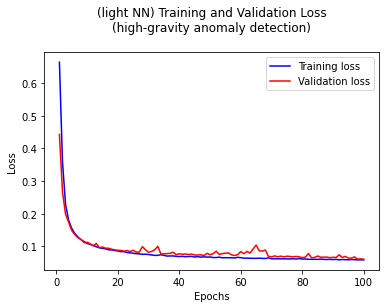

In [21]:
# Extract training and validation loss from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, c="blue", label='Training loss')
plt.plot(epochs, val_loss, c="red", label='Validation loss')
plt.title('(light NN) Training and Validation Loss\n(high-gravity anomaly detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# y_pred has shape (9473, 4)
y_vect_pred = model.predict(X_test)

y_pred = np.argmax(y_vect_pred, axis=1)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)


# Display a classification report
print("\n(light NN) Classification Report (high-gravity anomaly detection)\n")
print(classification_report(y_test, y_pred))


(light NN) Classification Report (high-gravity anomaly detection)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4401
           1       0.97      0.87      0.92       726
           2       0.92      0.94      0.93       678
           3       1.00      1.00      1.00       530

    accuracy                           0.98      6335
   macro avg       0.97      0.95      0.96      6335
weighted avg       0.98      0.98      0.98      6335



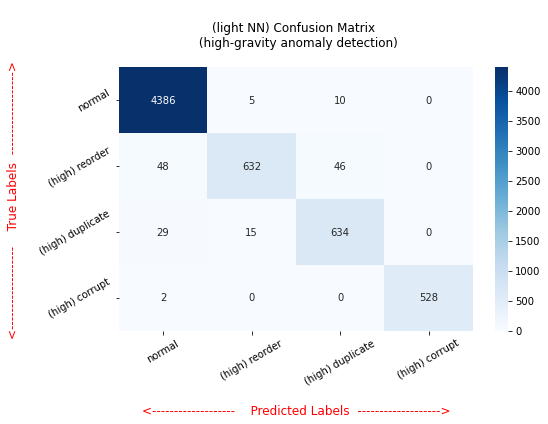

In [23]:
labaled_classes = ['normal','(high) reorder', '(high) duplicate','(high) corrupt']
classes = np.unique(y_train) 

classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)

plt.title("\n(light NN) Confusion Matrix \n (high-gravity anomaly detection)\n")
plt.tight_layout()
plt.show()

_**b. Case of more complex Architecture**_

Next, we will try more complex architecture with two dropout layers, l2 regularization and a more complex _**(64x32)**_ architecture. 

In [24]:
start_time = time.time()

# Define your model
complex_model = models.Sequential()

# Add the input layer and the first hidden layer
complex_model.add(layers.Dense(64, activation='relu', input_shape=(22,), kernel_regularizer=regularizers.l2(0.01)))
complex_model.add(layers.Dropout(0.5))
# Add more hidden layers if needed
complex_model.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
complex_model.add(layers.Dropout(0.5))

# Output layer with softmax activation for multiclass classification
complex_model.add(layers.Dense(4, activation='softmax'))

# Compile the model
complex_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use categorical_crossentropy if your labels are one-hot encoded
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

complex_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 64)                1472      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_4 (Dense)              (None, 32)                2080      
_________________________________________________________________
dropout_1 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_5 (Dense)              (None, 4)                 132       
Total params: 3,684
Trainable params: 3,684
Non-trainable params: 0
_________________________________________________________________


In [25]:
# Train the model and store the history
history = complex_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid))

print(f"Training completed in +{(time.time()-start_time)//60:.2f} min.")

Epoch 1/100
528/528 [==============================] - 2s 4ms/step - loss: 1.1508 - accuracy: 0.7533 - val_loss: 0.6837 - val_accuracy: 0.8431
Epoch 2/100
528/528 [==============================] - 2s 4ms/step - loss: 0.6292 - accuracy: 0.8400 - val_loss: 0.4566 - val_accuracy: 0.8780
Epoch 3/100
528/528 [==============================] - 2s 4ms/step - loss: 0.4876 - accuracy: 0.8710 - val_loss: 0.3851 - val_accuracy: 0.9039
Epoch 4/100
528/528 [==============================] - 2s 4ms/step - loss: 0.4363 - accuracy: 0.8879 - val_loss: 0.3466 - val_accuracy: 0.9293
Epoch 5/100
528/528 [==============================] - 2s 4ms/step - loss: 0.4063 - accuracy: 0.8975 - val_loss: 0.3219 - val_accuracy: 0.9294
Epoch 6/100
528/528 [==============================] - 2s 5ms/step - loss: 0.3824 - accuracy: 0.9050 - val_loss: 0.3118 - val_accuracy: 0.9350
Epoch 7/100
528/528 [==============================] - 3s 5ms/step - loss: 0.3755 - accuracy: 0.9090 - val_loss: 0.2947 - val_accuracy: 0.9416

Epoch 58/100
528/528 [==============================] - 2s 4ms/step - loss: 0.2679 - accuracy: 0.9317 - val_loss: 0.1999 - val_accuracy: 0.9605
Epoch 59/100
528/528 [==============================] - 2s 4ms/step - loss: 0.2649 - accuracy: 0.9322 - val_loss: 0.1878 - val_accuracy: 0.9635
Epoch 60/100
528/528 [==============================] - 3s 5ms/step - loss: 0.2622 - accuracy: 0.9324 - val_loss: 0.1924 - val_accuracy: 0.9614
Epoch 61/100
528/528 [==============================] - 3s 5ms/step - loss: 0.2572 - accuracy: 0.9351 - val_loss: 0.1965 - val_accuracy: 0.9555
Epoch 62/100
528/528 [==============================] - 2s 4ms/step - loss: 0.2572 - accuracy: 0.9346 - val_loss: 0.1888 - val_accuracy: 0.9599
Epoch 63/100
528/528 [==============================] - 2s 4ms/step - loss: 0.2554 - accuracy: 0.9358 - val_loss: 0.1976 - val_accuracy: 0.9543
Epoch 64/100
528/528 [==============================] - 2s 4ms/step - loss: 0.2552 - accuracy: 0.9365 - val_loss: 0.1958 - val_accuracy:

In [26]:
results = complex_model.evaluate(X_test, y_test)
dict(zip(complex_model.metrics_names, results))

198/198 [==============================] - 0s 1ms/step - loss: 0.2067 - accuracy: 0.9522


{'loss': 0.20668868720531464, 'accuracy': 0.9521704912185669}

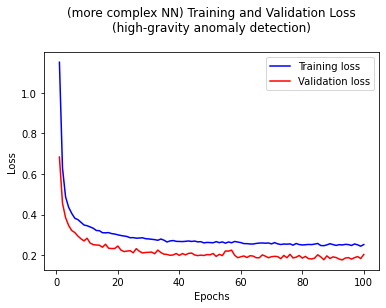

In [27]:
# Extract training and validation loss from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, c="blue", label='Training loss')
plt.plot(epochs, val_loss, c="red", label='Validation loss')
plt.title('(more complex NN) Training and Validation Loss\n(high-gravity anomaly detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
# y_pred has shape (9473, 4)
y_vect_pred = complex_model.predict(X_test)

y_pred = np.argmax(y_vect_pred, axis=1)

# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display a classification report
print("\n(more complex NN) Classification Report (high-gravity anomaly detection)\n")
print(classification_report(y_test, y_pred))


(more complex NN) Classification Report (high-gravity anomaly detection)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4401
           1       0.97      0.82      0.89       726
           2       0.95      0.76      0.84       678
           3       1.00      0.99      1.00       530

    accuracy                           0.95      6335
   macro avg       0.97      0.89      0.92      6335
weighted avg       0.95      0.95      0.95      6335



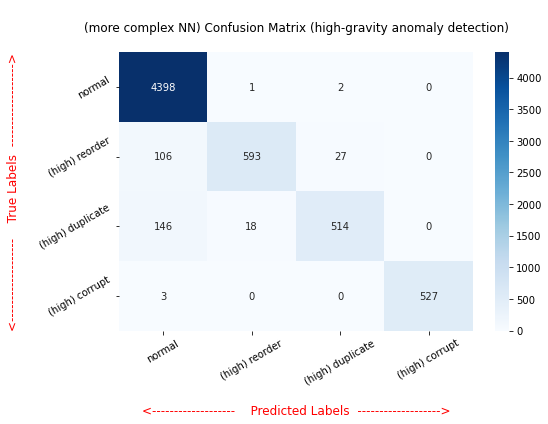

In [29]:
labaled_classes = ['normal','(high) reorder', '(high) duplicate','(high) corrupt']
classes = np.unique(y_train) 

classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labaled_classes, rotation=30)
plt.yticks(classes, labaled_classes, rotation=30)
plt.xlabel("<-------------------    Predicted Labels  ------------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<-------------------    True Labels  ------------------->",  fontsize=12, color="red", labelpad=18)
plt.title("\n(more complex NN) Confusion Matrix (high-gravity anomaly detection)\n")
plt.tight_layout()
plt.show()

_**c. Discussion**_

The problem of multi-class classification, and as we saw in the exploratory data analysis step, is not so complex. This explain the ability of sampler architecture to obtain mush better performance compared to the more complex one. 

Thus, we will pick the sampler variante as a representatif of neural network in our use case.